#Atualizando o modelo

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
Tesla T4


In [ ]:
#subindo as imagens novamente

from google.colab import drive
drive.mount('/content/drive')
!cp -r "/content/drive/MyDrive/Arquivos_para_Collab/Projeto_IA_REAL" /content/
BASE_DIR = "/content/Projeto_IA_REAL"

TRAIN_DIR = f"{BASE_DIR}/train"
VAL_DIR = f"{BASE_DIR}/val"
TEST_DIR = f"{BASE_DIR}/test"

Mounted at /content/drive


Vou utilizar um transform customizado com o intuito de criar um filtro passa alta, vou aderir novas informações para o modelo através das diferenças de ruídos entre imagens reais e imagens feitas por IA.

In [ ]:
class HighPassTransform:
    def __call__(self, image):
        image = image.unsqueeze(0)  # [1,3,H,W]
        kernel = torch.tensor([
                [[0, -1, 0],
                [-1, 4, -1],
                [0, -1, 0]]], dtype=torch.float32)


        kernel = kernel.repeat(3, 1, 1, 1)

        filtered = F.conv2d(image, kernel, padding=1, groups=3)

        filtered = filtered.squeeze(0)

        # NORMALIZAÇÃO LOCAL DO HIGH-PASS
        filtered = filtered - filtered.mean()
        filtered = filtered / (filtered.std() + 1e-6)

        output = torch.cat([image.squeeze(0), filtered], dim=0)

        return output




##Pipeline de transforms

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    HighPassTransform()
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    HighPassTransform()
])

##Datasets e Dataloader (códigos do notebook 1)

In [ ]:
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=val_transform)

In [ ]:
img, label = train_dataset[0]
print(img.shape)

torch.Size([6, 224, 224])


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

##Modelo

RGB → usa pesos pré-treinados

High-pass → reaproveita padrão inicial

In [ ]:
model_atualizado = models.resnet18(pretrained=True)

#pesos treinados da resnet
old_weights = model_atualizado.conv1.weight.clone()
#ajustando a entrada para 6 canais
model_atualizado.conv1 = nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3, bias=False)

with torch.no_grad():
    model_atualizado.conv1.weight[:, :3, :, :] = old_weights
    model_atualizado.conv1.weight[:, 3:, :, :] = old_weights

#ajustando saída para as 2 classes
model_atualizado.fc = nn.Linear(model_atualizado.fc.in_features, 2)
print(model_atualizado)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


ResNet(
  (conv1): Conv2d(6, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
for param in model_atualizado.parameters():
    param.requires_grad = False

for param in model_atualizado.layer4.parameters():
    param.requires_grad = True

for param in model_atualizado.fc.parameters():
    param.requires_grad = True

In [ ]:
#colocando o model na device(gpu)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model_atualizado = model_atualizado.to(device)

cuda


Colocando um markdown aqui porque eu mudei o balanceamento de imagens reais e IA e os pesos talvez não sejam mais necessários! Segue o notebook que você vai entender o contexto.

In [ ]:
# #weights = torch.tensor([1.9900, 0.6678]).to(device)

# loss_fn = nn.CrossEntropyLoss(weight=weights)

# optimizer = optim.Adam(
#     filter(lambda p: p.requires_grad, model_atualizado.parameters()),
#     lr=0.001
# )

##Treinando o modelo novo

In [ ]:
# epochs = 5

# for epoch in range(epochs):

#     model_atualizado.train()
#     train_loss = 0

#     for images, labels in train_loader:

#         images = images.to(device)
#         labels = labels.to(device)

#         optimizer.zero_grad()

#         outputs = model_atualizado(images)
#         loss = loss_fn(outputs, labels)

#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item()

#     train_loss /= len(train_loader)

#     # ===== VAL =====
#     model_atualizado.eval()
#     val_loss = 0
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for images, labels in val_loader:

#             images = images.to(device)
#             labels = labels.to(device)

#             outputs = model_atualizado(images)
#             loss = loss_fn(outputs, labels)

#             val_loss += loss.item()

#             _, preds = torch.max(outputs, 1)

#             correct += (preds == labels).sum().item()
#             total += labels.size(0)

#     val_loss /= len(val_loader)
#     accuracy = correct / total

#     print(f"Epoch {epoch+1}/{epochs}")
#     print(f"Train Loss: {train_loss:.4f}")
#     print(f"Val Loss: {val_loss:.4f}")
#     print(f"Val Accuracy: {accuracy:.4f}")
#     print("-" * 30)

Epoch 1/5
Train Loss: 0.3116
Val Loss: 0.1843
Val Accuracy: 0.9530
------------------------------
Epoch 2/5
Train Loss: 0.0791
Val Loss: 0.0679
Val Accuracy: 0.9799
------------------------------
Epoch 3/5
Train Loss: 0.0358
Val Loss: 0.0836
Val Accuracy: 0.9664
------------------------------
Epoch 4/5
Train Loss: 0.0208
Val Loss: 0.0774
Val Accuracy: 0.9732
------------------------------
Epoch 5/5
Train Loss: 0.0054
Val Loss: 0.0469
Val Accuracy: 0.9866
------------------------------


O modelo por aqui até tá tendo um bom desempenho no treino, mas ainda precisamos ajustar algumas questões para evitar esse tipo de a falta de generalização.

1: Corrigindo o normalize para 6 canais já que temos => [RGB | High-pass]

Canais 0–2 → RGB (0 a 1, normalizado pelo ToTensor)

Canais 3–5 → High-pass (valores podem ser negativos e maiores)


Calculando a média por imagem no treino apenas e depois aplicando um normalize em todos.

In [ ]:
# mean = torch.zeros(6)
# std = torch.zeros(6)

# for img, _ in train_dataset:
#     mean += img.mean(dim=[1, 2])
#     std += img.std(dim=[1, 2])

# mean /= len(train_dataset)
# std /= len(train_dataset)

# print("Mean:", mean)
# print("Std:", std)

Salvando como markdown porque o cálculo dessa média demora um bom tempo

Mean: tensor([0.4614, 0.4520, 0.4096, 0.0236, 0.0239, 0.0222])

Std: tensor([0.2284, 0.2159, 0.2154, 0.3628, 0.3513, 0.3376])

In [ ]:
mean = torch.tensor([0.4614, 0.4520, 0.4096, 0.0236, 0.0239, 0.0222])
std = torch.tensor([0.2284, 0.2159, 0.2154, 0.3628, 0.3513, 0.3376])

In [ ]:
print("Mean:", mean)
print("Std:", std)

Mean: tensor([0.4614, 0.4520, 0.4096, 0.0236, 0.0239, 0.0222])
Std: tensor([0.2284, 0.2159, 0.2154, 0.3628, 0.3513, 0.3376])


Agora atualizando os transforms com esses valores de média e std

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    HighPassTransform(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    HighPassTransform(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

Recriando os datasets e dataloaders com os novos transforms!

In [ ]:
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=val_transform)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,   # aumenta paralelismo
    pin_memory=True  # melhora transferência pra GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True)

In [ ]:
img, label = train_dataset[0]
print(img.shape)

torch.Size([6, 224, 224])


##Novo treino após distribuição nova dos dados

In [ ]:
# epochs = 5

# for epoch in range(epochs):

#     model_atualizado.train()
#     train_loss = 0

#     for images, labels in train_loader:

#         images = images.to(device)
#         labels = labels.to(device)

#         optimizer.zero_grad()

#         outputs = model_atualizado(images)
#         loss = loss_fn(outputs, labels)

#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item()

#     train_loss /= len(train_loader)

#     # ===== VAL =====
#     model_atualizado.eval()
#     val_loss = 0
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for images, labels in val_loader:

#             images = images.to(device)
#             labels = labels.to(device)

#             outputs = model_atualizado(images)
#             loss = loss_fn(outputs, labels)

#             val_loss += loss.item()

#             _, preds = torch.max(outputs, 1)

#             correct += (preds == labels).sum().item()
#             total += labels.size(0)

#     val_loss /= len(val_loader)
#     accuracy = correct / total

#     print(f"Epoch {epoch+1}/{epochs}")
#     print(f"Train Loss: {train_loss:.4f}")
#     print(f"Val Loss: {val_loss:.4f}")
#     print(f"Val Accuracy: {accuracy:.4f}")
#     print("-" * 30)

Epoch 1/5
Train Loss: 0.0087
Val Loss: 0.0794
Val Accuracy: 0.9732
------------------------------
Epoch 2/5
Train Loss: 0.0099
Val Loss: 0.0539
Val Accuracy: 0.9732
------------------------------
Epoch 3/5
Train Loss: 0.0185
Val Loss: 0.0707
Val Accuracy: 0.9664
------------------------------
Epoch 4/5
Train Loss: 0.0100
Val Loss: 0.0383
Val Accuracy: 0.9866
------------------------------
Epoch 5/5
Train Loss: 0.0040
Val Loss: 0.0346
Val Accuracy: 0.9799
------------------------------


Testando esse modelo

In [ ]:
# idx = 0

# model_atualizado.eval()

# with torch.no_grad():
#     for images, labels in external_loader:

#         images = images.to(device)
#         labels = labels.to(device)

#         outputs = model_atualizado(images)
#         probs = torch.softmax(outputs, dim=1)
#         _, preds = torch.max(outputs, 1)

#         for i in range(len(images)):

#             real_label = external_dataset.classes[labels[i]]
#             pred_label = external_dataset.classes[preds[i]]
#             confidence = probs[i][preds[i]].item()

#             img_path = external_dataset.samples[idx][0]
#             file_name = os.path.basename(img_path)

#             print(f"Imagem: {file_name}")
#             print(f"Real: {real_label} | Pred: {pred_label} | Confiança: {confidence:.4f}")
#             print("-" * 40)

#             idx += 1

Imagem: a_image01.jpg Real: ai | Pred: real | Confiança: 0.9885

----------------------------------------

Imagem: a_image03.jpg Real: ai | Pred: real | Confiança: 0.9980

----------------------------------------

Imagem: a_image04.jpg Real: ai | Pred: real | Confiança: 0.9772

----------------------------------------

Imagem: a_image05.jpg Real: ai | Pred: real | Confiança: 0.5338

----------------------------------------

Imagem: a_image2.jpg Real: ai | Pred: ai | Confiança: 0.7057

----------------------------------------

Imagem: r_image01.jpg Real: real | Pred: real | Confiança: 0.9964

---------------------------------------

Imagem: r_image02.jpg Real: real | Pred: real | Confiança: 0.9983

----------------------------------------

Imagem: r_image03.jpg Real: real | Pred: real | Confiança: 0.9997

----------------------------------------

Imagem: r_image04.jpg Real: real | Pred: real | Confiança: 1.0000

----------------------------------------

Imagem: r_image05.jpg Real: real | Pred: real | Confiança: 0.9999

----------------------------------------

O modelo apresentou viés significativo, aprendendo padrões superficiais do dataset em vez de características intrínsecas de imagens geradas por IA. Eu vou ter que aumentar o dataset do kaggle pra fazer um modelo realmente bom e que consiga generalizar melhor! Adicionei mais 1752 imagens variadas para tentar melhorar esse resultado! Abaixo segue as quantidades de cada pasta

test ai: 154

test real: 225

total: 379

train ai: 694

train real: 1007

total: 1701

val ai: 281

val real: 256

total: 537

total ai: 1129

total real: 1488

TOTAL: 2617 Imagens

**Se precisar de weights** testar o código abaixo

In [ ]:
weights = torch.tensor([1.16, 0.88]).to(device)
loss_fn = nn.CrossEntropyLoss(weight=weights)

In [ ]:

optimizer = optim.Adam(
   filter(lambda p: p.requires_grad, model_atualizado.parameters()),
   lr=1e-4
)

In [ ]:
epochs = 5

for epoch in range(epochs):

    model_atualizado.train()
    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_atualizado(images)
        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ===== VAL =====
    model_atualizado.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_atualizado(images)
            loss = loss_fn(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    accuracy = correct / total

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {accuracy:.4f}")
    print("-" * 30)

Epoch 1/5
Train Loss: 0.4429
Val Loss: 0.3429
Val Accuracy: 0.8492
------------------------------
Epoch 2/5
Train Loss: 0.0968
Val Loss: 0.3835
Val Accuracy: 0.8473
------------------------------
Epoch 3/5
Train Loss: 0.0398
Val Loss: 0.3466
Val Accuracy: 0.8585
------------------------------
Epoch 4/5
Train Loss: 0.0393
Val Loss: 0.3377
Val Accuracy: 0.8622
------------------------------
Epoch 5/5
Train Loss: 0.0439
Val Loss: 0.3616
Val Accuracy: 0.8715
------------------------------


In [ ]:
img, _ = train_dataset[0]

print(img.shape)          # deve ser [6, 224, 224]
print(img[:3].mean())     # RGB ~ 0.4–0.5
print(img[3:].mean())     # HP ~ 0 (IMPORTANTÍSSIMO)
print(img[3:].std())      # HP ~ 1

torch.Size([6, 224, 224])
tensor(0.5556)
tensor(-0.0659)
tensor(2.8587)


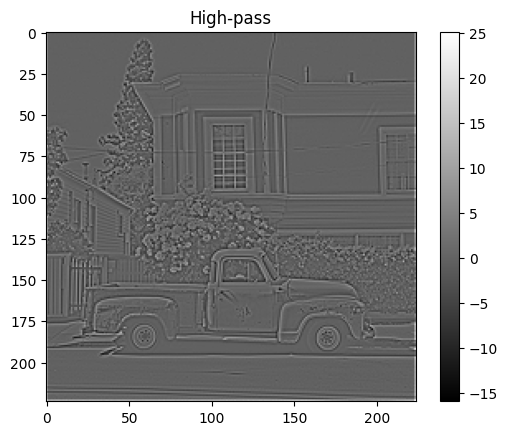

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img[3].cpu(), cmap='gray')
plt.title("High-pass")
plt.colorbar()

In [ ]:
EXTERNAL_DIR = f"{BASE_DIR}/external_test"
TEST_DIR = f"{BASE_DIR}/test"
external_dataset = datasets.ImageFolder(
    root=EXTERNAL_DIR,
    transform=val_transform
)
external_loader  = DataLoader(
    external_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True)


In [ ]:
import os
idx = 0

model_atualizado.eval()

with torch.no_grad():
    for images, labels in external_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_atualizado(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        for i in range(len(images)):

            real_label = external_dataset.classes[labels[i]]
            pred_label = external_dataset.classes[preds[i]]
            confidence = probs[i][preds[i]].item()

            img_path = external_dataset.samples[idx][0]
            file_name = os.path.basename(img_path)

            print(f"Imagem: {file_name}")
            print(f"Real: {real_label} | Pred: {pred_label} | Confiança: {confidence:.4f}")
            print("-" * 40)

            idx += 1

Imagem: a_image01.jpg
Real: ai | Pred: ai | Confiança: 0.9999
----------------------------------------
Imagem: a_image03.jpg
Real: ai | Pred: real | Confiança: 0.9157
----------------------------------------
Imagem: a_image04.jpg
Real: ai | Pred: ai | Confiança: 0.8219
----------------------------------------
Imagem: a_image05.jpg
Real: ai | Pred: ai | Confiança: 0.8691
----------------------------------------
Imagem: a_image06.jpg
Real: ai | Pred: real | Confiança: 0.9561
----------------------------------------
Imagem: a_image2.jpg
Real: ai | Pred: ai | Confiança: 0.6173
----------------------------------------
Imagem: r_image01.jpg
Real: real | Pred: real | Confiança: 0.8071
----------------------------------------
Imagem: r_image02.jpg
Real: real | Pred: real | Confiança: 0.9999
----------------------------------------
Imagem: r_image03.jpg
Real: real | Pred: real | Confiança: 0.8628
----------------------------------------
Imagem: r_image04.jpg
Real: real | Pred: real | Confiança: